# 03_Epi_Refinement
## Xiaonan Wang
## 16Sep2026

In [5]:
#%matplotlib nbagg
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import pandas as pd
from os import listdir
from os.path import isfile, join
import re
import anndata
# import scvi

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(name='gene_cmap', colors=['lightgrey', '#a1a1ce', 'purple', '#301934']) 
sc.settings.set_figure_params(dpi=80, color_map='viridis', vector_friendly=False,  dpi_save=300)

In [6]:
import sys

project_dir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1"

if project_dir not in sys.path:
    sys.path.append(project_dir)

import source

In [3]:
sc.logging.print_header()

Package,Version
numpy,2.4.5
matplotlib,3.10.9
scanpy,1.11.5
pandas,2.3.3
anndata,0.12.14
Component,Info
Python,"3.11.6 | packaged by conda-forge | (main, Oct 3 2023, 10:40:35) [GCC 12.3.0]"
OS,Linux-4.18.0-553.81.1.el8_10.x86_64-x86_64-with-glibc2.28
CPU,"5/64 logical CPU cores, x86_64"
GPU,No GPU found


In [7]:
datadir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/data/Spatial/"
outdir = "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Data/External_Data/Xu_NC2026_human/analysis_v1/write_all/"

## Step0 - Read In Files

In [5]:
x_epi = sc.read_h5ad(datadir + "epithelial_xenium.h5ad")

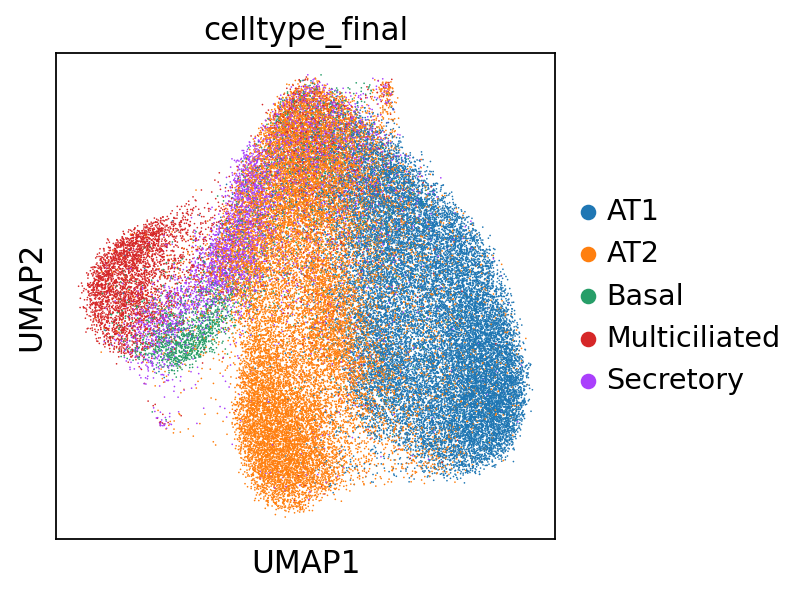

In [6]:
sc.pl.umap(x_epi, color='celltype_final')

## Step1 - Refine Cell Type By Leiden Clustering

In [7]:
sc.tl.leiden(x_epi, resolution = 2, key_added = 'Leiden_epi')

running Leiden clustering


/tmp/ipykernel_2630818/1778852392.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(x_epi, resolution = 2, key_added = 'Leiden_epi')


    finished: found 22 clusters and added
    'Leiden_epi', the cluster labels (adata.obs, categorical) (0:00:12)


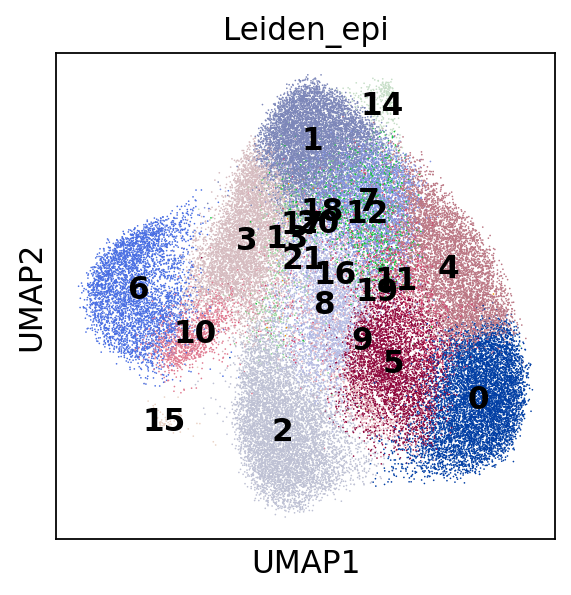

In [8]:
sc.pl.umap(x_epi, color='Leiden_epi', legend_loc='on data')

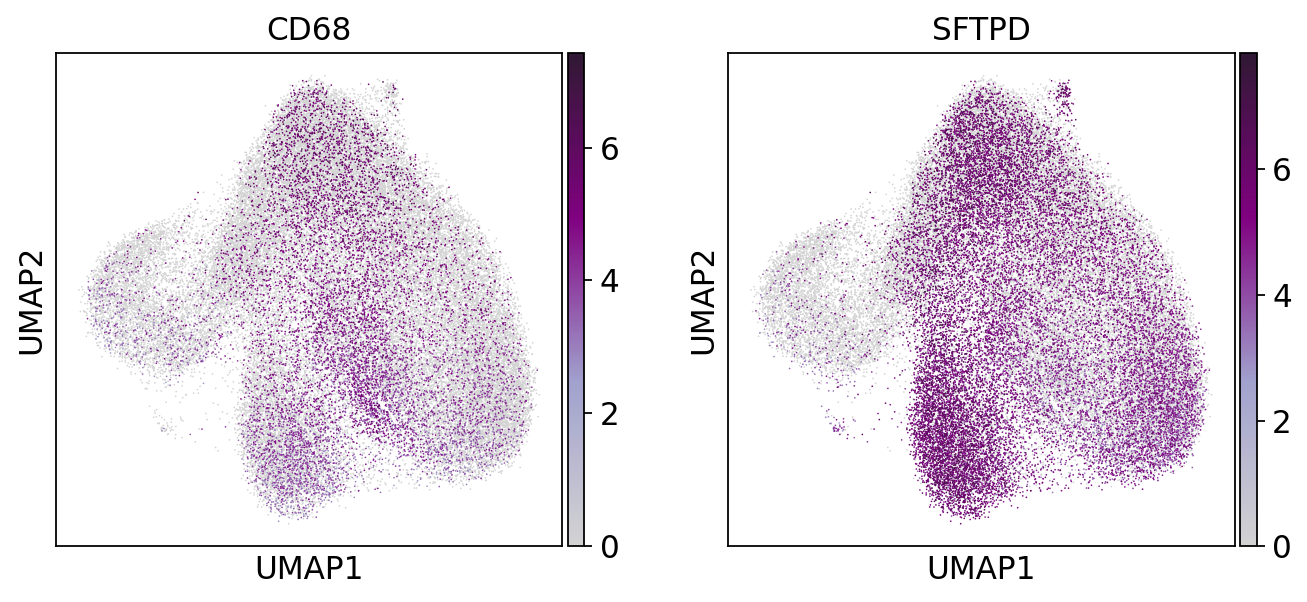

In [10]:
sc.pl.umap(x_epi, color=['CD68', 'SFTPD'], color_map=cmap, use_raw=False)

In [10]:
sc.tl.rank_genes_groups(x_epi, groupby='Leiden_epi', n_genes=x_epi.shape[1], method='wilcoxon', key_added='DE_Leiden_epi')

ranking genes
    finished: added to `.uns['DE_Leiden_epi']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:02)


/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/miniconda3/envs/scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/miniconda3/envs/scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/dssg/home/acct-svetoslav_cha

In [11]:
pd.set_option("display.max_columns", None)

In [12]:
pd.DataFrame(x_epi.uns['DE_Leiden_epi']['names']).head(50)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
0,EMP2,SELENOH,MUC1,DMBT1,EMP2,PECAM1,TMC5,SELENOH,SERPINE1,CD68,KRT17,CXCL8,PECAM1,SFTPD,SELENOH,SEC11C,SFTPD,MYO6,DNAJB1,PIM1,SEMA3B,PIM1
1,SCEL,FCGR1A,CD44,SERPINA3,AGER,HLA-E,AGR3,CEACAM6,MMP2,TYROBP,KRT5,CXCL2,SERPINE1,WIF1,S100A12,ATP1B1,DMBT1,SFTPD,APOE,MAPK1,SPP1,PECAM1
2,CEACAM6,CXCL10,SFTPD,BPIFB1,CEACAM6,FN1,CP,PCOLCE2,FN1,CD74,MET,ICAM1,IL1RL1,CXCL2,GPR171,CP,SELENOH,DUOX1,HSPA8,WIF1,CD163,FASN
3,AGER,TRPC6,STEAP4,LTF,SCEL,KRT7,CCDC78,MARCO,IL1RL1,AIF1,CXCL8,CCL2,FCN3,CD44,KRT5,MUC1,MX1,TMPRSS2,PEBP4,TMPRSS2,MX1,STEAP4
4,CD47,IGF1,FASN,S100B,SEMA3B,CDH5,FOXJ1,CXCL10,PECAM1,VSIG4,F3,SERPINE1,CDH5,DMBT1,FCGR1A,HP,FN1,PLA2G4F,RND1,CDH1,AIF1,HMGCS1
5,VEGFA,RERGL,WIF1,EHF,VEGFA,SERPINE1,TC2N,HGF,HIF1A,FCGR3A,EHF,CEACAM6,FLT1,FASN,CLEC12A,MET,HMGB1,PLVAP,DPP4,SFTPD,SELENOH,HIF1A
6,ICAM1,CXCL13,HMGCS1,KRT17,DAPK2,MMP2,IGFBP7,AGER,CD44,CD163,CD44,DNAJB1,AGER,PEBP4,IRF8,TP53,SFTA2,FASN,GNG11,FN1,SERPINE1,FN1
7,SEMA3B,MMRN1,MTUS1,MUC5B,ICAM1,EMP2,EHF,CD300E,FLT1,CTSL,ITGB4,FOS,IL7R,CXCL8,CTLA4,KLK11,IL23A,APOE,WNT2,SIRT1,SCEL,HMGB2
8,KRT7,CD28,PEBP4,HP,PDPN,IL1RL1,CD24,CXCR2,CDH5,CD44,CP,EMP2,TMEM100,SERPINE1,TM4SF4,EPCAM,VSIG4,BANK1,GZMA,PLA2G4F,MMP2,IGFBP7
9,DAPK2,SPP1,HIF1A,FOS,COL8A1,APP,BAIAP2L1,SPP1,HLA-E,TGFB1,APP,AGER,VWF,AREG,CXCL13,AGR3,MIF,WIF1,CCL2,CEACAM6,TNFRSF18,TM4SF18


In [13]:
cluster_to_celltype_epi = {
    "0":  "AT1",                    # AT1
    "1":  "Mixed",                  # Immune contaminant
    "2":  "AT2",                    # AT2
    "3":  "MUC5B+ Secretory",       # MUC5B+ Secretory/SMG-like
    "4":  "AT1",               # AT1-like/Mesothelial-like
    "5":  "Endothelial",            # Endothelial contaminant
    "6":  "Ciliated",               # Ciliated
    "7":  "Mixed",                  # Immune contaminant
    "8":  "Endothelial",            # Activated Endothelial/Stromal
    "9":  "Mixed",                  # Macrophage contaminant
    "10": "KRT17+ Basal",           # KRT17+ Basal
    "11": "CXCL8+ Epithelial",      # CXCL8+ Inflammatory Epithelial
    "12": "Endothelial",            # Capillary Endothelial
    "13": "Mixed",                  # FOXI1+ Ionocyte-like/AT2-mixed
    "14": "Mixed",                  # Immune contaminant
    "15": "Club",                   # Club/Secretory
    "16": "AT2",                    # Inflammatory AT2
    "17": "Mixed",                  # Mixed AT2/Endothelial/Myeloid
    "18": "Mixed",                  # Stromal/Vascular contaminant
    "19": "AT2",                    # WIF1+ AT2-like
    "20": "Mixed",                  # Macrophage/Stromal contaminant
    "21": "Endothelial",            # Endothelial contaminant
}

In [14]:
x_epi.obs["CellType"] = (
    x_epi.obs["Leiden_epi"]
    .astype(str)
    .map(cluster_to_celltype_epi)
)

In [15]:
x_epi.obs["Leiden_epi"].value_counts()

Leiden_epi
0     7150
1     6998
2     6816
3     5538
4     5513
5     4248
6     4116
7     3812
8     3465
9     1613
10    1297
11    1160
12    1131
13     571
14     349
15      60
16      34
17      24
18      10
19       5
20       3
21       2
Name: count, dtype: int64

In [16]:
# Reordered by biological similarity:
# alveolar → airway epithelial → endothelial → mixed

cluster_to_celltype_epi = {
    # Alveolar epithelial cells
    "0":  "AT1",
    "4":  "AT1",
    "2":  "AT2",
    "16": "AT2",
    "19": "AT2",

    # Activated/transitional epithelial
    "11": "CXCL8+ Epithelial",

    # Airway epithelial cells
    "10": "KRT17+ Basal",
    "15": "Club",
    "3":  "MUC5B+ Secretory",
    "6":  "Ciliated",

    # Endothelial contaminants
    "5":  "Endothelial",
    "8":  "Endothelial",
    "12": "Endothelial",
    "21": "Endothelial",

    # Mixed or uncertain populations
    "1":  "Mixed",
    "7":  "Mixed",
    "9":  "Mixed",
    "13": "Mixed",
    "14": "Mixed",
    "17": "Mixed",
    "18": "Mixed",
    "20": "Mixed",
}

cluster_order_epi = list(cluster_to_celltype_epi.keys())

In [17]:
x_epi.obs["Leiden_epi"] = pd.Categorical(
    x_epi.obs["Leiden_epi"].astype(str),
    categories=cluster_order_epi,
    ordered=True,
)

x_epi.obs["CellType"] = (
    x_epi.obs["Leiden_epi"]
    .astype(str)
    .map(cluster_to_celltype_epi)
)

celltype_order_epi = [
    "AT1",
    "AT2",
    "CXCL8+ Epithelial",
    "KRT17+ Basal",
    "Club",
    "MUC5B+ Secretory",
    "Ciliated",
    "Endothelial",
    "Mixed",
]

x_epi.obs["CellType"] = pd.Categorical(
    x_epi.obs["CellType"],
    categories=celltype_order_epi,
    ordered=True,
)

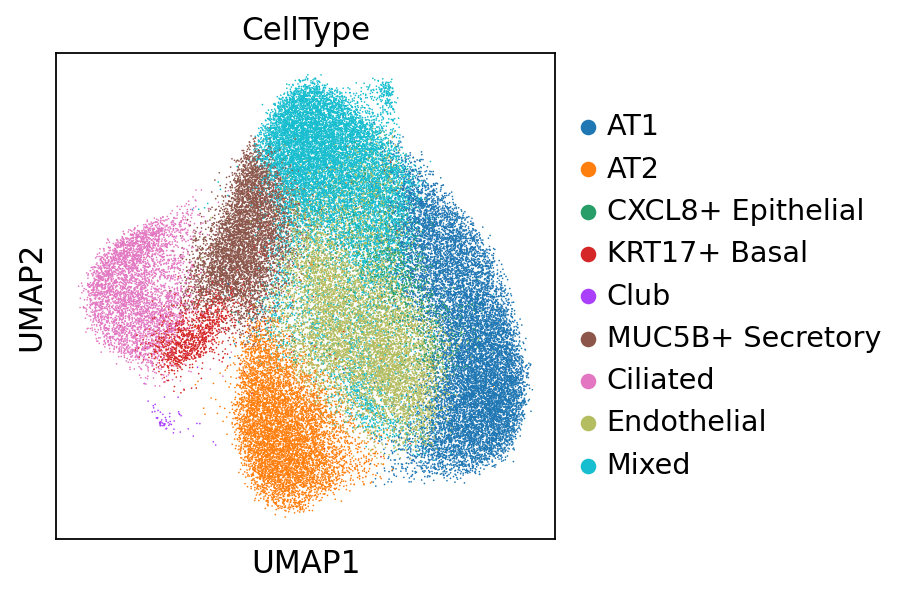

In [18]:
sc.pl.umap(x_epi, color='CellType')

In [19]:
epi_marker_groups = {
    "AT1": [
        "AGER",
        # "PDPN",
        "EMP2",
        "SEMA3B",
    ],

    # "AT1-like": [
    #     "UPK3B",
    #     "WT1",
    #     "COL8A1",
    # ],

    "AT2": [
        "SFTPD",
        # "SFTA2",
        # "ETV5",
        "WIF1",
        "FASN",
    ],

    "Epi": [
        "CXCL8",
        "CXCL2",
        # "ICAM1",
        "SERPINE1",
        # "CDKN1A",
    ],

    "Basal": [
        "KRT5",
        # "KRT15",
        "KRT17",
        # "TP63",
        "ITGB4",
    ],

    "Club": [
        "MUC1",
        # "SCEL",
        "KLF5",
        "TMPRSS2",
    ],

    "Secretory": [
        "MUC5B",
        "BPIFB1",
        "DMBT1",
        # "SPDEF",
        # "AGR3",
    ],

    "Ciliated": [
        "FOXJ1",
        "CCDC78",
        # "TP73",
        "TMC5",
    ],

    # "Ionocyte": [
    #     "FOXI1",
    #     "CFTR",
    #     "ASCL3",
    # ],

    "Endothelial": [
        "PECAM1",
        # "CDH5",
        "VWF",
        "KDR",
        # "FLT1",
    ],

    "Immune": [
        "CD68",
        # "TYROBP",
        "CD3D",
        "NKG7",
        # "PDGFRA",
    ],
}

In [20]:
available_epi_markers = {
    group: [
        gene for gene in genes
        if gene in x_epi.var_names
    ]
    for group, genes in epi_marker_groups.items()
}

available_epi_markers = {
    group: genes
    for group, genes in available_epi_markers.items()
    if len(genes) > 0
}

for group, genes in available_epi_markers.items():
    print(f"{group}: {genes}")

AT1: ['AGER', 'EMP2', 'SEMA3B']
AT2: ['SFTPD', 'WIF1', 'FASN']
Epi: ['CXCL8', 'CXCL2', 'SERPINE1']
Basal: ['KRT5', 'KRT17', 'ITGB4']
Club: ['MUC1', 'KLF5', 'TMPRSS2']
Secretory: ['MUC5B', 'BPIFB1', 'DMBT1']
Ciliated: ['FOXJ1', 'CCDC78', 'TMC5']
Endothelial: ['PECAM1', 'VWF', 'KDR']
Immune: ['CD68', 'CD3D', 'NKG7']


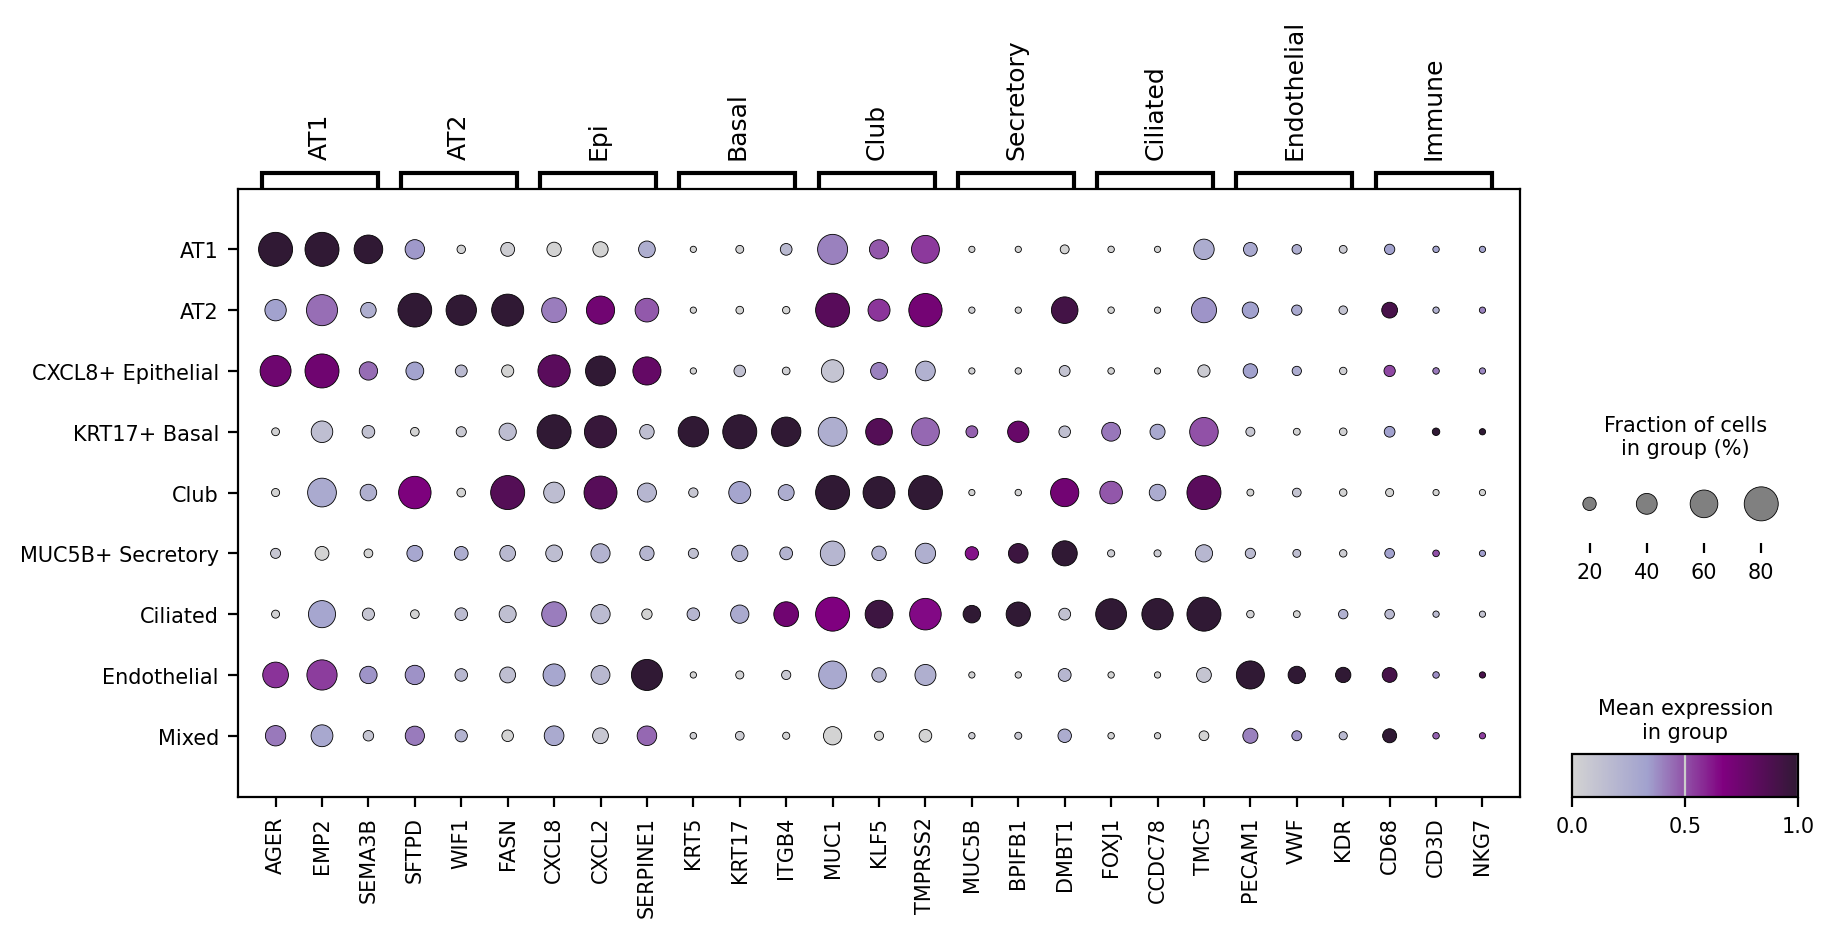

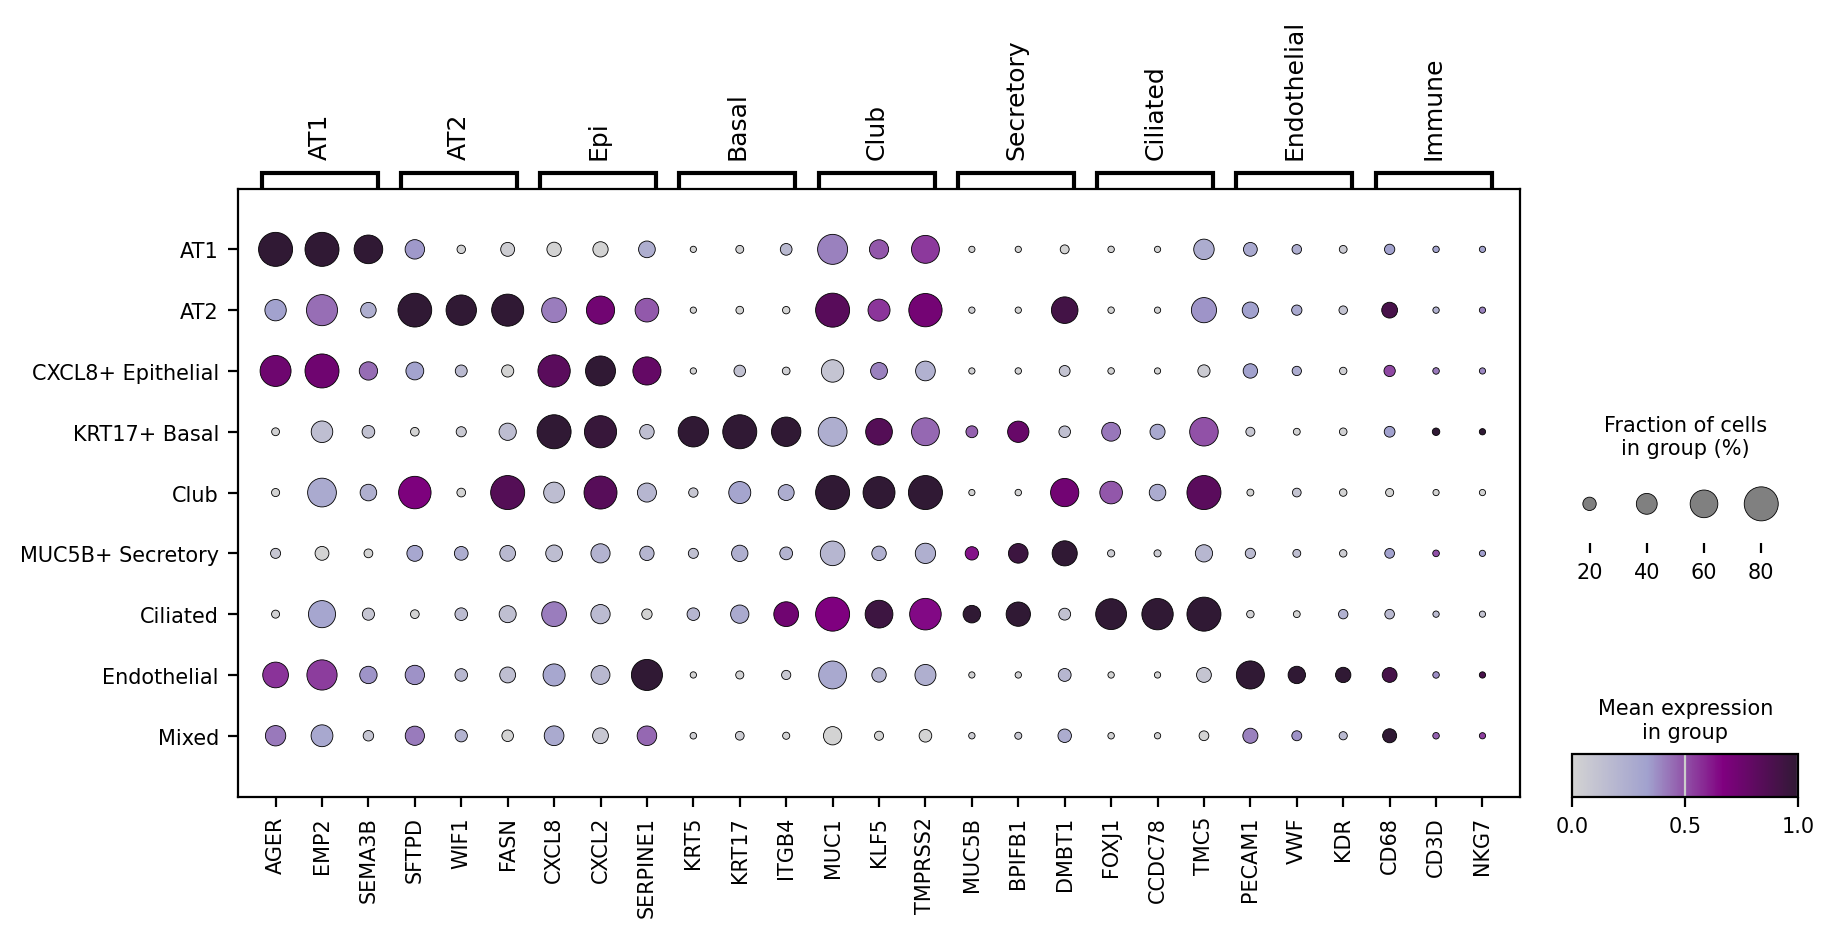

In [21]:
sc.settings.set_figure_params(
    dpi=100,
    dpi_save=300,
    fontsize=9,
    frameon=False,
)

epi_dotplot = sc.pl.dotplot(
    x_epi,
    var_names=available_epi_markers,
    groupby="CellType",
    categories_order=celltype_order_epi,
    use_raw=False,
    standard_scale="var",
    cmap=cmap,
    dot_min=0,
    dot_max=0.8,
    smallest_dot=5,
    figsize=(10, 4),
    return_fig=True,
    show=False,
)

epi_dotplot.style(
    dot_edge_color="black",
    dot_edge_lw=0.30,
    largest_dot=150,
)

epi_dotplot.make_figure()
epi_dotplot.savefig(
    "Xenium_epithelial_celltype_annotation_dotplot.pdf"
)

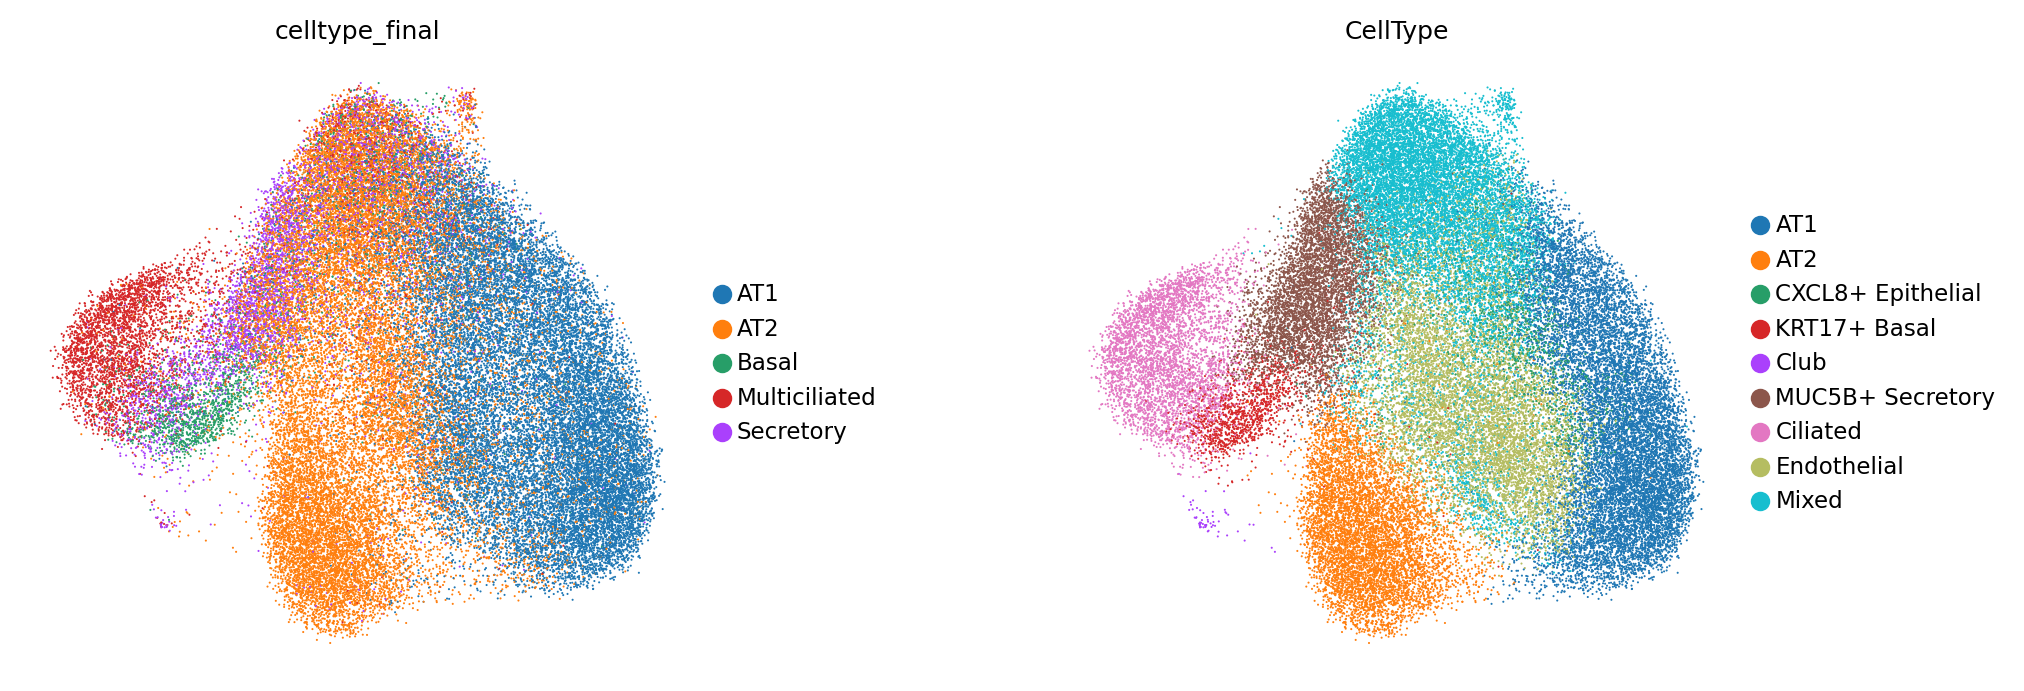

In [22]:
sc.pl.umap(x_epi, color=['celltype_final', 'CellType'], wspace=0.4)

## Step2 - Check %AT2 Subtypes Within Each Core in Each Tissue

In [24]:
x_all = sc.read_h5ad(datadir + "xenium.h5ad")

In [25]:
core_cols = ["donor_id", "tma_id", "core_id"]

alveolar_epi_order = [
    "AT1",
    "AT2",
]

# ------------------------------------------------------------
# Total number of cells in each core from x_all
# ------------------------------------------------------------
all_obs = x_all.obs.copy()

all_obs["tissue_annotation"] = (
    all_obs["tissue_annotation"]
    .astype("object")
    .fillna("None")
    .astype(str)
)

all_core_summary = (
    all_obs
    .groupby(
        core_cols + ["tissue_annotation"],
        observed=True,
    )
    .size()
    .rename("n_all_cells")
    .reset_index()
)

# ------------------------------------------------------------
# AT1 and AT2 numbers from x_epi
# ------------------------------------------------------------
epi_obs = x_epi.obs.copy()

epi_obs["tissue_annotation"] = (
    epi_obs["tissue_annotation"]
    .astype("object")
    .fillna("None")
    .astype(str)
)

epi_counts = (
    epi_obs[
        epi_obs["CellType"].isin(alveolar_epi_order)
    ]
    .groupby(
        core_cols + ["tissue_annotation", "CellType"],
        observed=True,
    )
    .size()
    .rename("n_epi_cells")
    .reset_index()
)

# ------------------------------------------------------------
# Add zero for an epithelial type absent from a core
# ------------------------------------------------------------
complete_grid = (
    all_core_summary[
        core_cols + ["tissue_annotation", "n_all_cells"]
    ]
    .assign(_key=1)
    .merge(
        pd.DataFrame({
            "CellType": alveolar_epi_order,
            "_key": 1,
        }),
        on="_key",
    )
    .drop(columns="_key")
)

alveolar_epithelial_abundance_pct_long = (
    complete_grid
    .merge(
        epi_counts,
        on=core_cols + ["tissue_annotation", "CellType"],
        how="left",
    )
)

alveolar_epithelial_abundance_pct_long["n_epi_cells"] = (
    alveolar_epithelial_abundance_pct_long["n_epi_cells"]
    .fillna(0)
)

alveolar_epithelial_abundance_pct_long["percent_of_all_cells"] = (
    100
    * alveolar_epithelial_abundance_pct_long["n_epi_cells"]
    / alveolar_epithelial_abundance_pct_long["n_all_cells"]
)

alveolar_epithelial_abundance_pct_long["CellType"] = pd.Categorical(
    alveolar_epithelial_abundance_pct_long["CellType"],
    categories=alveolar_epi_order,
    ordered=True,
)

# Retain only the final columns
alveolar_epithelial_abundance_pct_long = (
    alveolar_epithelial_abundance_pct_long[
        core_cols
        + [
            "tissue_annotation",
            "CellType",
            "percent_of_all_cells",
        ]
    ]
    .sort_values(
        ["tissue_annotation", "donor_id", "tma_id", "core_id", "CellType"]
    )
    .reset_index(drop=True)
)

In [26]:
display(alveolar_epithelial_abundance_pct_long.head())

,donor_id,tma_id,core_id,tissue_annotation,CellType,percent_of_all_cells
0,D1,TMA1,D1.c1,A,AT1,3.118728
1,D1,TMA1,D1.c1,A,AT2,3.520148
2,D1,TMA1,D1.c2,A,AT1,3.355705
3,D1,TMA1,D1.c2,A,AT2,3.334399
4,D2,TMA1,D2.c3,A,AT1,2.604104


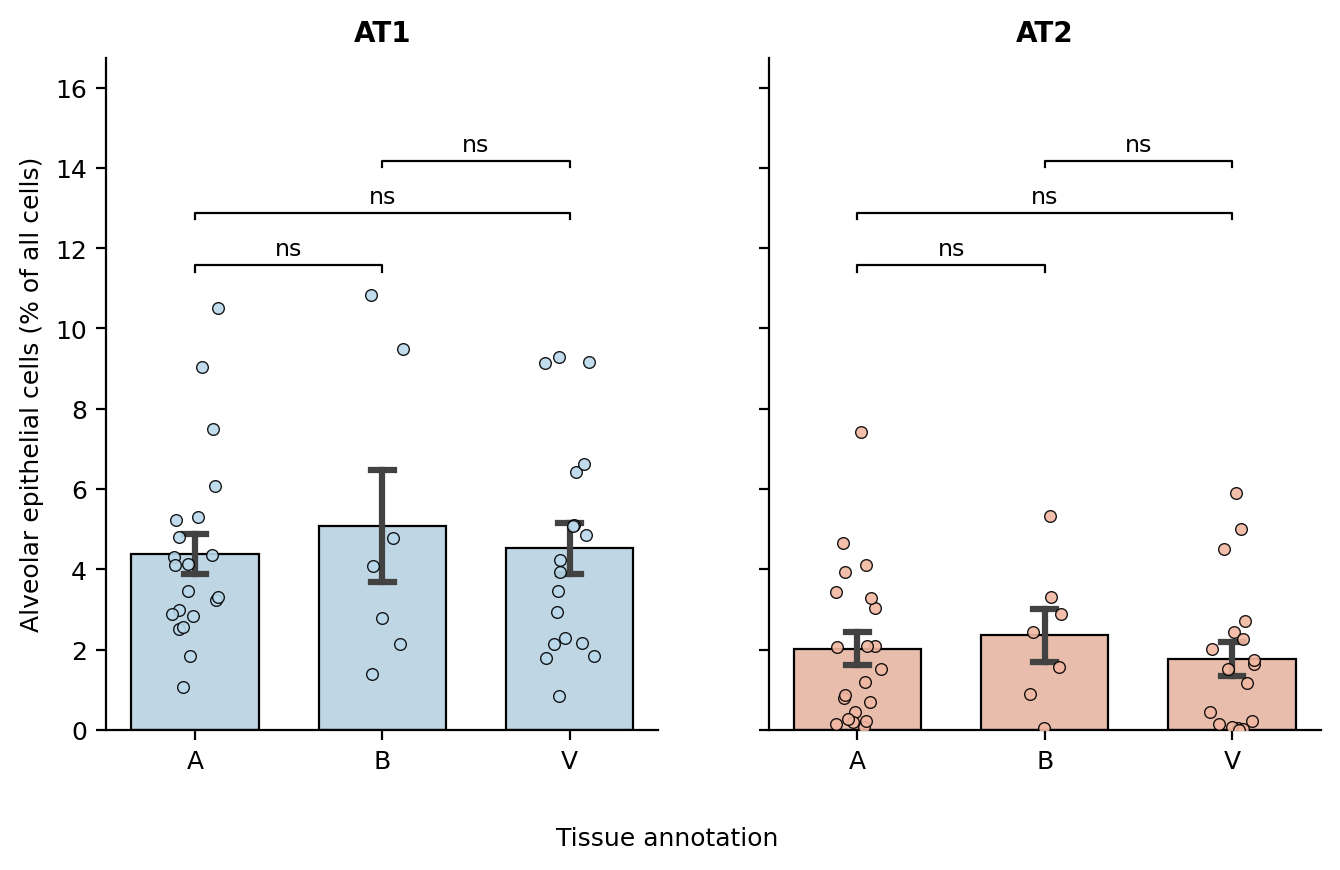

In [27]:
alveolar_palette = {
    "AT1": "#B9D9EB",  # blue macaron
    "AT2": "#F2B8A2",  # peach macaron
}

fig, axes, alveolar_epi_summary, alveolar_epi_stats = (
    source.plot_macrophage_pct_by_tissue(
        alveolar_epithelial_abundance_pct_long,
        tissue_order=("A", "B", "V"),
        macrophage_order=("AT1", "AT2"),
        comparisons=(
            ("A", "B"),
            ("A", "V"),
            ("B", "V"),
        ),
        value_col="percent_of_all_cells",
        ylabel="Alveolar epithelial cells (% of all cells)",
        palette=alveolar_palette,
        show_ns=True,
        save="AT1_AT2_abundance_by_tissue.pdf",
    )
)

In [28]:
display(
    alveolar_epi_stats[
        [
            "CellType",
            "tissue1",
            "tissue2",
            "n_paired_donors",
            "p_value",
            "p_adj",
            "significance",
        ]
    ].round(4)
)

,CellType,tissue1,tissue2,n_paired_donors,p_value,p_adj,significance
0,AT1,A,B,6,0.4375,0.7335,ns
1,AT1,A,V,17,0.6112,0.7335,ns
2,AT1,B,V,7,0.4688,0.7335,ns
3,AT2,A,B,6,1.0000,1.0000,ns
4,AT2,A,V,17,0.1901,0.7335,ns
5,AT2,B,V,7,0.5781,0.7335,ns


In [29]:
x_epi.write(outdir + 'epi_updated.h5ad')

In [4]:
x_epi = sc.read_h5ad(outdir + 'epi_updated.h5ad')